In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, precision_recall_curve,
    average_precision_score, ConfusionMatrixDisplay, f1_score, cohen_kappa_score, make_scorer
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from scipy.stats import randint

In [ ]:
from ucimlrepo import fetch_ucirepo

random_seed = 6

np.random.seed(seed=random_seed)

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets.values.ravel()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_seed)
X_val, X_test, y_val, y_test = train_test_split(X, y, test_size=0.5, random_state=random_seed)

In [ ]:
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)


In [ ]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        n_estimators=100,
        random_state=random_seed,
        n_jobs=-1
    ))
])

In [ ]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=random_seed)
param_dist = {
    "model__n_estimators":      randint(100, 600),
    "model__max_depth":         [None, 5, 10, 20, 30],
    "model__min_samples_split": randint(2, 20),
    "model__min_samples_leaf":  randint(1, 10),
    "model__max_features":      ["sqrt", "log2", 0.5],
}

qwk_scorer = make_scorer(
    cohen_kappa_score,
    weights="quadratic"
)

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=50,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed),
    scoring=qwk_scorer,
    n_jobs=-1,
    random_state=random_seed
)

random_search.fit(X_train, y_train)
best_pipeline = random_search.best_estimator_

calibrated_pipe = CalibratedClassifierCV(best_pipeline, method="isotonic", cv=5)
calibrated_pipe.fit(X_train, y_train)

classes = best_pipeline.classes_
preprocessor_fit = best_pipeline.named_steps["preprocessor"]
rf_fit = best_pipeline.named_steps["model"]

Validation Accuracy: 0.78

Validation Classification Report:
               precision    recall  f1-score   support

     Level 0       0.84      0.95      0.89        81
     Level 1       1.00      0.31      0.48        32
     Level 2       0.65      0.88      0.75        17
     Level 3       0.52      0.92      0.67        12
     Level 4       1.00      0.56      0.71         9

    accuracy                           0.78       151
   macro avg       0.80      0.72      0.70       151
weighted avg       0.84      0.78      0.76       151

Macro F1 : 0.6995
Quadratic Weighted Kappa : 0.7931


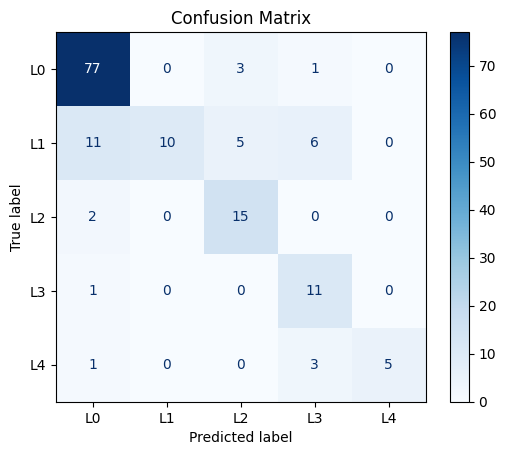

In [ ]:
y_val_pred = calibrated_pipe.predict(X_val)

accuracy_val = accuracy_score(y_val, y_val_pred)
classification_val_rep = classification_report(y_val, y_val_pred,
      target_names=[f"Level {c}" for c in classes], zero_division=0)
macro_f1_val = f1_score(y_val, y_val_pred, average="macro", zero_division=0)
qwk_val = cohen_kappa_score(y_val, y_val_pred, weights="quadratic")

print(f"Validation Accuracy: {accuracy_val:.2f}")
print("\nValidation Classification Report:\n", classification_val_rep)
print(f"Macro F1 : {macro_f1_val:.4f}")
print(f"Quadratic Weighted Kappa : {qwk_val:.4f}")

cm  = confusion_matrix(y_val, y_val_pred, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"L{c}" for c in classes])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


Accuracy: 0.70

Classification Report:
               precision    recall  f1-score   support

     Level 0       0.80      0.98      0.88        83
     Level 1       1.00      0.04      0.08        23
     Level 2       0.47      0.42      0.44        19
     Level 3       0.48      0.65      0.56        23
     Level 4       1.00      0.50      0.67         4

    accuracy                           0.70       152
   macro avg       0.75      0.52      0.53       152
weighted avg       0.75      0.70      0.65       152

Macro F1 : 0.5261
Quadratic Weighted Kappa : 0.7831


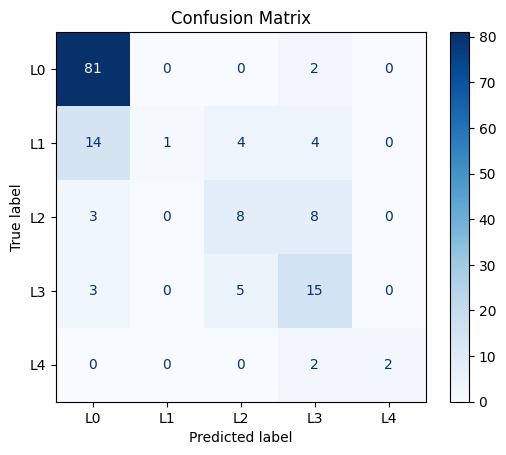

In [ ]:
y_pred = calibrated_pipe.predict(X_test)
y_proba = calibrated_pipe.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred,
      target_names=[f"Level {c}" for c in classes], zero_division=0)
macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
qwk = cohen_kappa_score(y_test, y_pred, weights="quadratic")

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)
print(f"Macro F1 : {macro_f1:.4f}")
print(f"Quadratic Weighted Kappa : {qwk:.4f}")
cm  = confusion_matrix(y_test, y_pred, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"L{c}" for c in classes])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

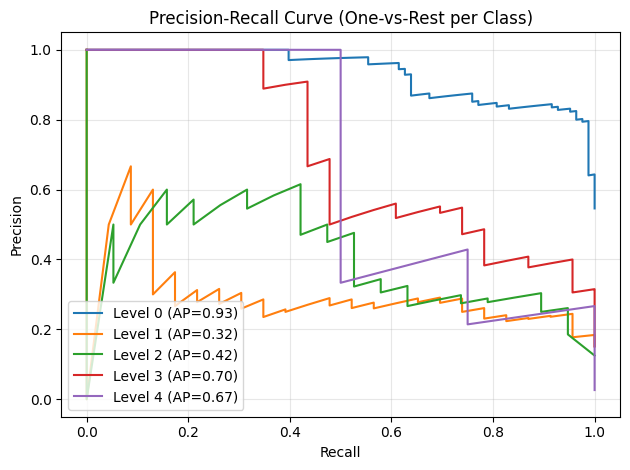

In [ ]:
fig, ax = plt.subplots()
for i, cls in enumerate(classes):
    binary_y = (y_test == cls).astype(int)
    prec, rec, _ = precision_recall_curve(binary_y, y_proba[:, i])
    ap = average_precision_score(binary_y, y_proba[:, i])
    ax.plot(rec, prec, label=f"Level {cls} (AP={ap:.2f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve (One-vs-Rest per Class)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


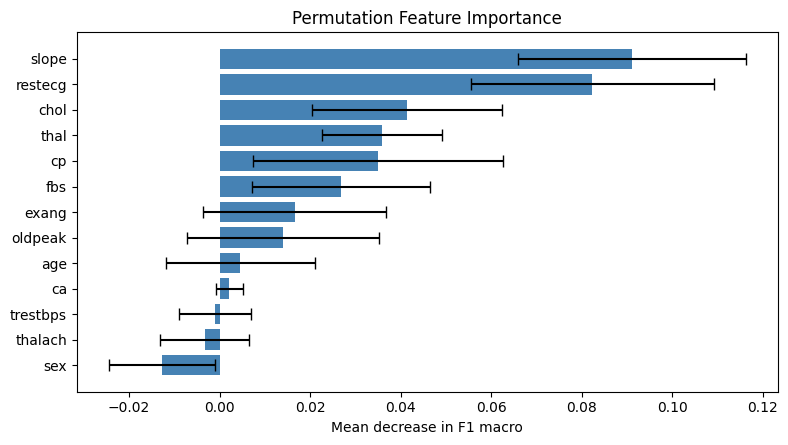

In [ ]:
perm_imp = permutation_importance(
    calibrated_pipe, X_test, y_test,
    n_repeats=10, scoring=qwk_scorer,
    random_state=random_seed
)

perm_df = pd.DataFrame({
    "feature":    numeric_features + categorical_features,
    "importance": perm_imp.importances_mean,
    "std":        perm_imp.importances_std,
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, len(perm_df) * 0.35))
ax.barh(perm_df["feature"], perm_df["importance"],
        xerr=perm_df["std"], color="steelblue", capsize=4)
ax.invert_yaxis()
ax.set_xlabel("Mean decrease in F1 macro")
ax.set_title("Permutation Feature Importance")
plt.tight_layout()
plt.show()


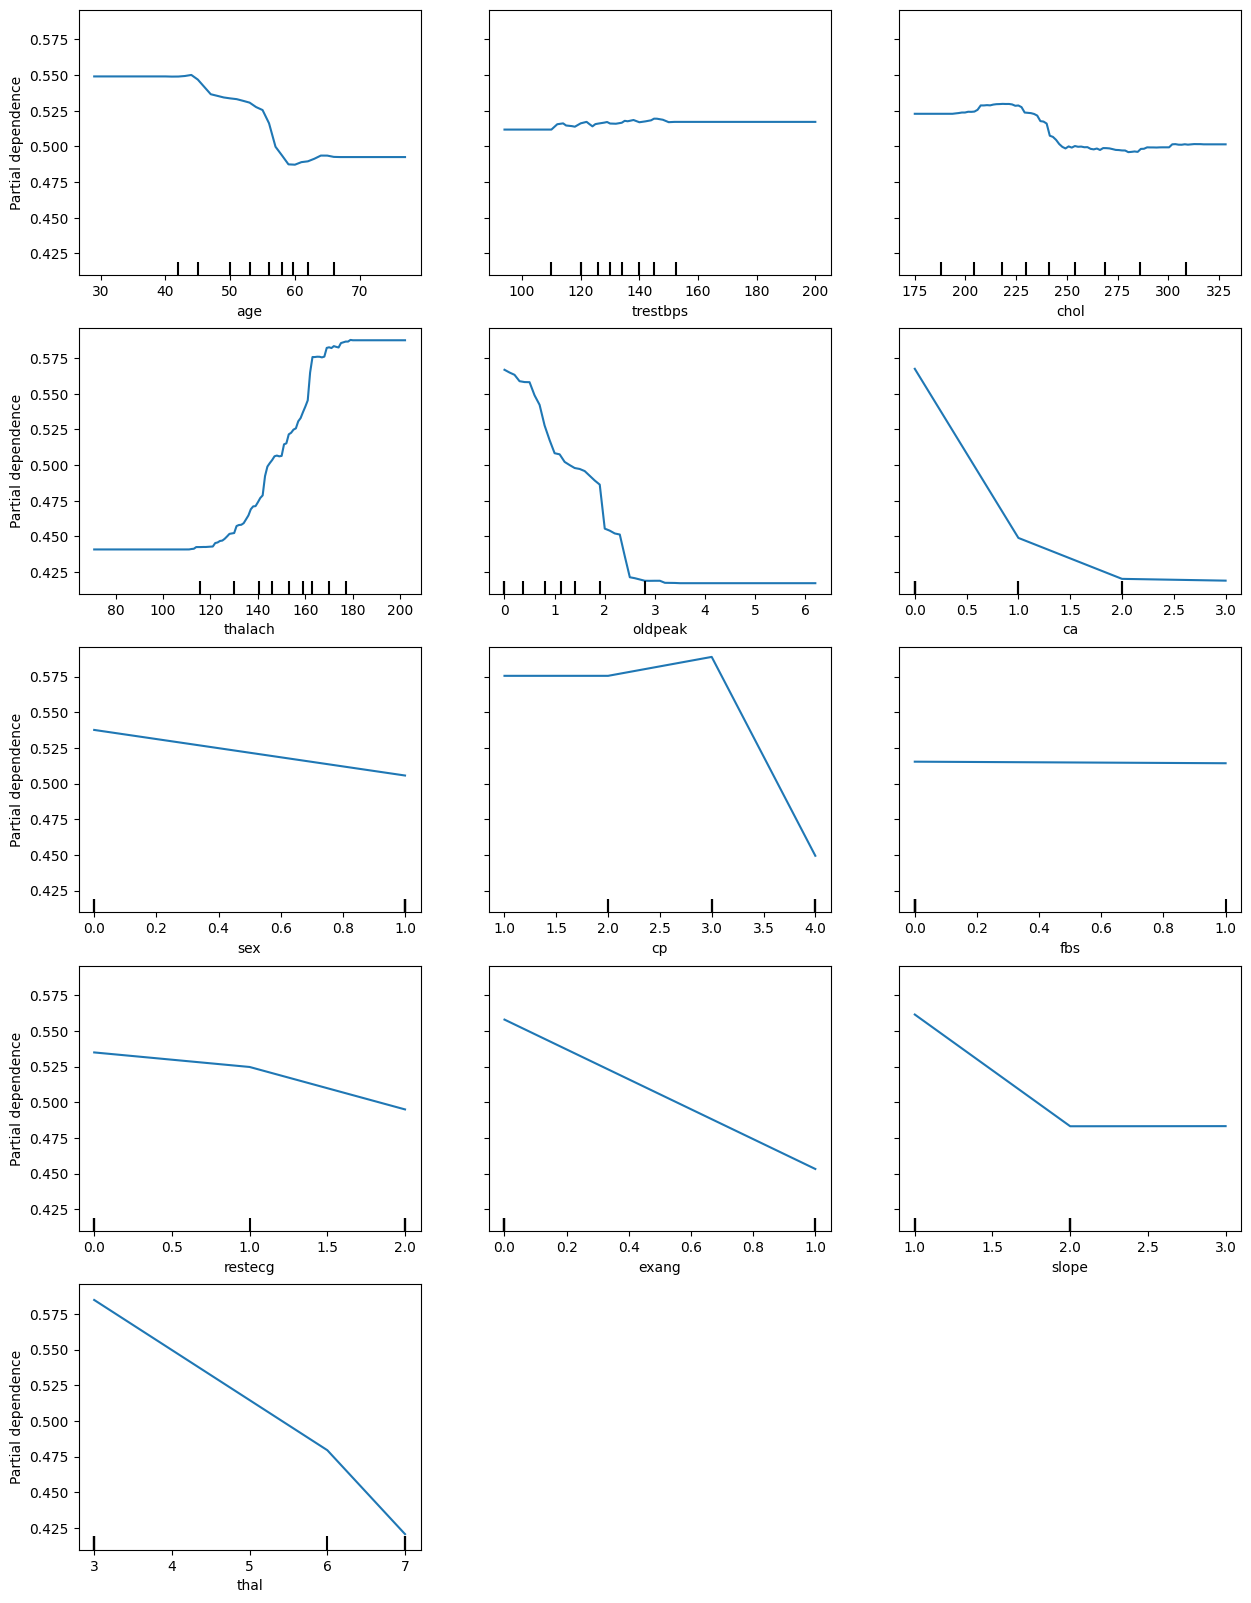

In [ ]:
fig, ax = plt.subplots(figsize=(15, 20))
display = PartialDependenceDisplay.from_estimator(
    calibrated_pipe,
    X.astype(float),
    numeric_features + categorical_features,
    target=0,
    ax=ax
)
plt.show()

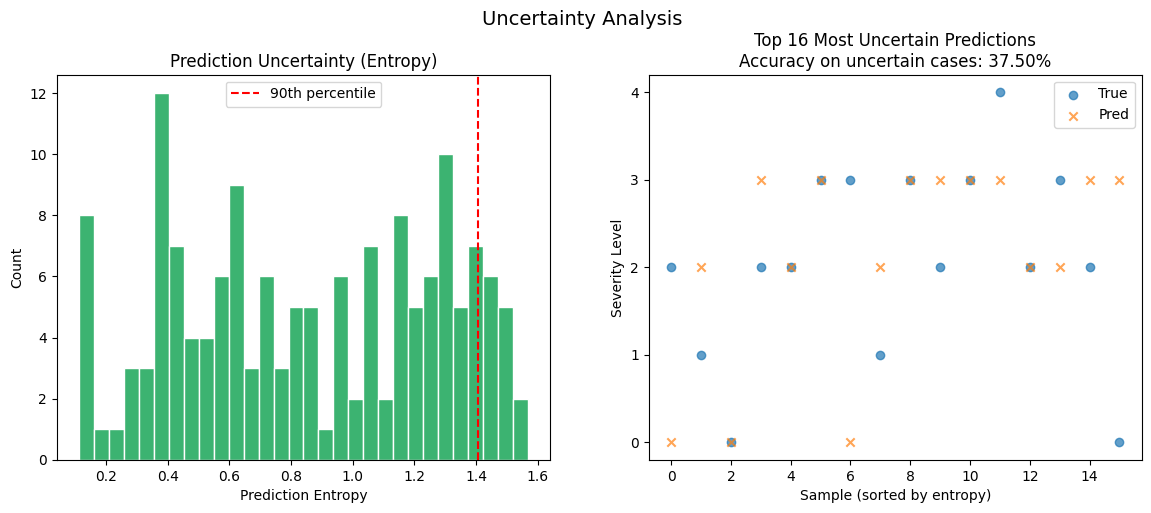

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Prediction Entropy (uncertainty) ---
entropy = -np.sum(y_proba * np.log(y_proba + 1e-10), axis=1)
ax1.hist(entropy, bins=30, color="mediumseagreen", edgecolor="white")
ax1.axvline(np.percentile(entropy, 90), color="red", linestyle="--",
            label="90th percentile")
ax1.set_xlabel("Prediction Entropy")
ax1.set_ylabel("Count")
ax1.set_title("Prediction Uncertainty (Entropy)")
ax1.legend()

# --- Most Uncertain Cases ---
uncertain_threshold = np.percentile(entropy, 90)
uncertain_mask      = entropy >= uncertain_threshold
uncertain_true      = y_test[uncertain_mask]
uncertain_pred      = y_pred[uncertain_mask]
uncertain_correct   = (uncertain_true == uncertain_pred)

# Show true vs predicted for most uncertain samples
n_show = min(30, uncertain_mask.sum())
idx_sorted = np.argsort(entropy)[::-1][:n_show]
ax2.scatter(range(n_show), y_test[idx_sorted], label="True",  marker="o", alpha=0.7)
ax2.scatter(range(n_show), y_pred[idx_sorted], label="Pred",  marker="x", alpha=0.7)
ax2.set_xlabel("Sample (sorted by entropy)")
ax2.set_ylabel("Severity Level")
ax2.set_title(f"Top {n_show} Most Uncertain Predictions\n"
              f"Accuracy on uncertain cases: "
              f"{uncertain_correct.mean():.2%}")
ax2.legend()
ax2.set_yticks(list(classes))

plt.suptitle("Uncertainty Analysis", fontsize=14, y=1.01)
plt.show()

In [ ]:
print("\n=== Most Uncertain Cases (Top 10 by Entropy) ===")
top10_idx = np.argsort(entropy)[::-1][:10]
uncertain_report = X_test.iloc[top10_idx].copy()
uncertain_report["true_level"]  = y_test[top10_idx]
uncertain_report["pred_level"]  = y_pred[top10_idx]
uncertain_report["entropy"]     = entropy[top10_idx]
uncertain_report["max_prob"]    = y_proba[top10_idx].max(axis=1)
print(uncertain_report[["true_level", "pred_level", "entropy", "max_prob"]]
      .to_string())
print("\nLow max_prob + high entropy = model is most confused on these cases.")


=== Most Uncertain Cases (Top 10 by Entropy) ===
     true_level  pred_level   entropy  max_prob
243           2           0  1.567454  0.304840
224           1           2  1.567273  0.277962
183           0           0  1.516945  0.306833
292           2           3  1.515769  0.384999
229           2           2  1.515485  0.333207
6             3           3  1.500862  0.376358
109           3           0  1.476256  0.332693
270           1           2  1.459976  0.352509
296           3           3  1.451525  0.363017
158           2           3  1.442204  0.421027

Low max_prob + high entropy = model is most confused on these cases.
